Randomly selected patient: 3775


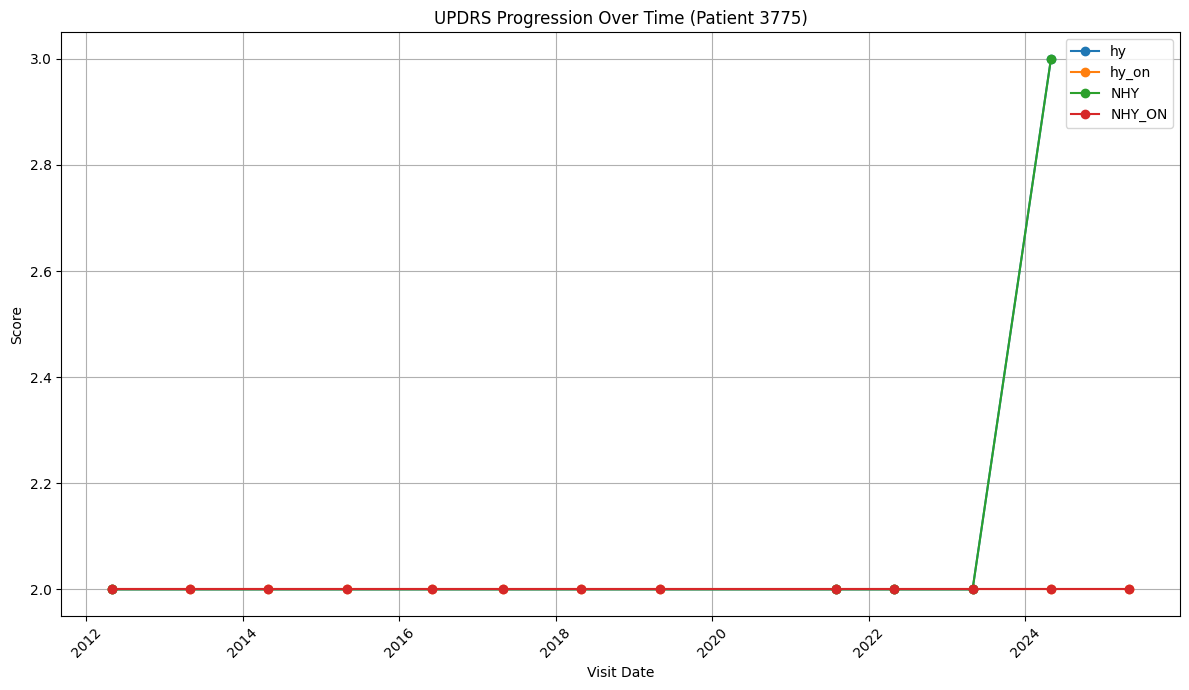

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------
# Load data
# -----------------------------
file_path = "/home/falconnier/Documents/PPMI_study_data_starting_point/PPMI_Curated_Data_Cut_Public_20251112.xlsx"

df = pd.read_excel(file_path)

# -----------------------------
# Clean and format data
# -----------------------------

# Convert visit_date (format like "10/2020") to datetime
df["visit_date"] = pd.to_datetime(df["visit_date"], format="%m/%Y", errors="coerce")

# Drop rows with missing PATNO or visit_date
df = df.dropna(subset=["PATNO", "visit_date"])

# -----------------------------
# Select random patient
# -----------------------------
random_patient = np.random.choice(df["PATNO"].unique())
patient_df = df[df["PATNO"] == random_patient].copy()

# Sort by date
patient_df = patient_df.sort_values("visit_date")

print(f"Randomly selected patient: {random_patient}")

# -----------------------------
# Columns to plot
# -----------------------------
score_columns = [
    # "updrs1_score",
    # "updrs2_score",
    # "updrs3_score",
    # "updrs3_score_on",
    # "updrs4_score",
    # "updrs_totscore",
    # "updrs_totscore_on",
    "hy",
    "hy_on",
    "NHY",
    "NHY_ON",
]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 7))

for col in score_columns:
    if col in patient_df.columns:
        temp = patient_df[["visit_date", col]].dropna()
        if not temp.empty:
            plt.plot(temp["visit_date"], temp[col], marker="o", label=col)

plt.xlabel("Visit Date")
plt.ylabel("Score")
plt.title(f"UPDRS Progression Over Time (Patient {random_patient})")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
